In [ ]:
! pip install statsforecast
! pip install utilsforecast

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('/content/daily_sales_french_bakery.csv', parse_dates=["ds"], index_col=["ds"])
df.groupby('unique_id').filter(lambda x: len(x) > 28)
df = df.drop(['unit_price'], axis=1)
df = df.sort_values('ds')
df.head()


,unique_id,y
ds,,
2021-01-02,CEREAL BAGUETTE,23.75
2021-01-02,BOULE 200G,6.60
2021-01-02,COUPE,8.25
2021-01-02,TRADITIONAL BAGUETTE,153.60
2021-01-02,GD KOUIGN AMANN,15.00


In [ ]:
# df['unique_id'].unique()

In [ ]:
daily_total = df.groupby('ds')['y'].sum().reset_index()

daily_total = daily_total.sort_values('ds')
daily_total.set_index('ds', inplace=True)

daily_total.head()

,y
ds,
2021-01-02,987.85
2021-01-03,1014.30
2021-01-04,461.90
2021-01-05,515.70
2021-01-06,0.00


In [ ]:
import seaborn as sns

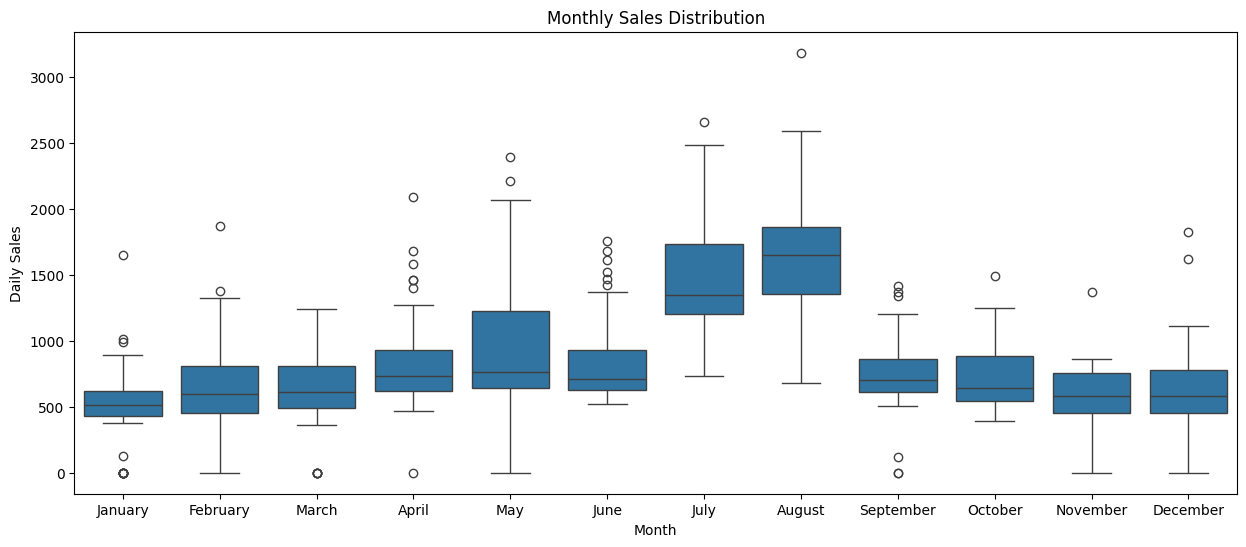

In [ ]:
daily_total['Month'] = daily_total.index.month_name()
plt.figure(figsize=(15,6))
sns.boxplot(x='Month', y='y', data=daily_total)
plt.title("Monthly Sales Distribution")
plt.xlabel("Month")
plt.ylabel("Daily Sales")
plt.show()

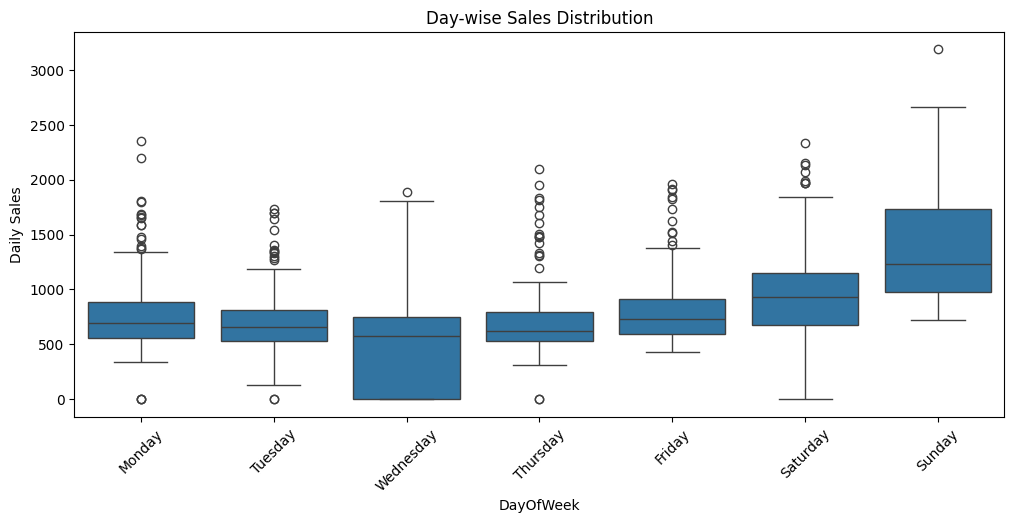

In [ ]:
daily_total['DayOfWeek'] = daily_total.index.day_name()

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.figure(figsize=(12,5))
sns.boxplot(x='DayOfWeek', y='y', data=daily_total, order=order)
plt.title("Day-wise Sales Distribution")
plt.xticks(rotation=45)
plt.ylabel("Daily Sales")
plt.show()

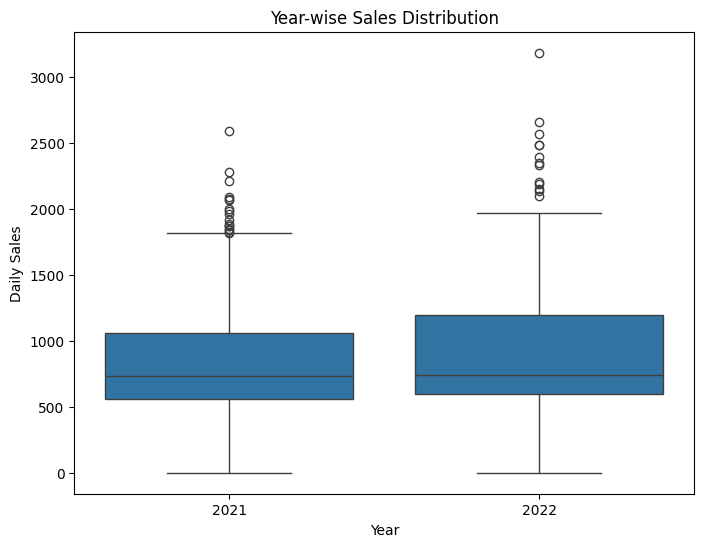

In [ ]:
daily_total['Year'] = daily_total.index.year

plt.figure(figsize=(8,6))
sns.boxplot(x='Year', y='y', data=daily_total)
plt.title("Year-wise Sales Distribution")
plt.ylabel("Daily Sales")
plt.show()

ADF

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
result = adfuller(daily_total['y'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Number of lags used:", result[2])
print("Number of observations:", result[3])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -2.655863245165531
p-value: 0.08199216288481187
Number of lags used: 20
Number of observations: 616

Critical Values:
1%: -3.4410103235939746
5%: -2.866243374831338
10%: -2.5692748053002195


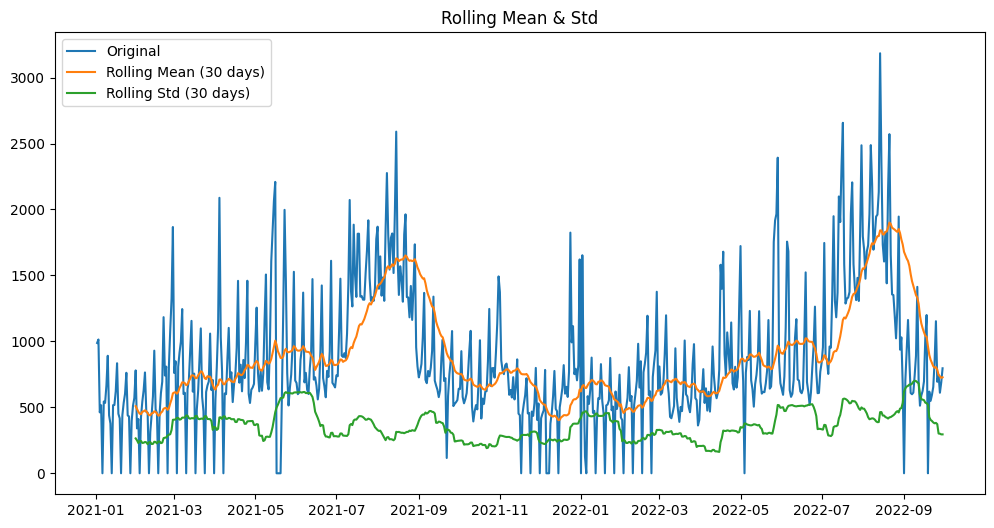

In [ ]:
rolling_mean = daily_total['y'].rolling(window=30).mean()
rolling_std = daily_total['y'].rolling(window=30).std()

plt.figure(figsize=(12,6))
plt.plot(daily_total['y'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean (30 days)')
plt.plot(rolling_std, label='Rolling Std (30 days)')
plt.legend()
plt.title("Rolling Mean & Std")
plt.show()

In [ ]:
daily_total['y_diff'] = daily_total['y'].diff()

daily_total = daily_total.dropna()
result_diff = adfuller(daily_total['y_diff'])

print("ADF after Differencing:", result_diff[0])
print("p-value after Differencing:", result_diff[1])

ADF after Differencing: -5.748599486130018
p-value after Differencing: 6.03975104759729e-07


KPSS


In [ ]:
from statsmodels.tsa.stattools import kpss

In [ ]:
result_kpss = kpss(daily_total['y'], regression='c')

print("KPSS Statistic:", result_kpss[0])
print("p-value:", result_kpss[1])
print("Lags Used:", result_kpss[2])

print("\nCritical Values:")
for key, value in result_kpss[3].items():
    print(f"{key}: {value}")

KPSS Statistic: 0.4577238461563574
p-value: 0.0522742042429494
Lags Used: 14

Critical Values:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


In [ ]:
result_kpss_diff = kpss(daily_total['y_diff'], regression='c')

print("KPSS Statistic (Differenced):", result_kpss_diff[0])
print("p-value (Differenced):", result_kpss_diff[1])

KPSS Statistic (Differenced): 0.04679838691164205
p-value (Differenced): 0.1


/tmp/ipython-input-1071/1392381851.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result_kpss_diff = kpss(daily_total['y_diff'], regression='c')


ACF/PACF

In [ ]:
series = daily_total['y_diff']

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Figure size 1000x800 with 0 Axes>

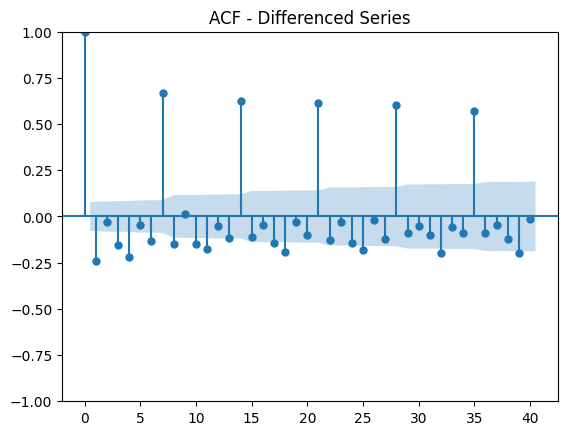

In [ ]:
plt.figure(figsize=(10,8))
plot_acf(daily_total['y_diff'], lags=40)
plt.title("ACF - Differenced Series")
plt.show()

<Figure size 1000x600 with 0 Axes>

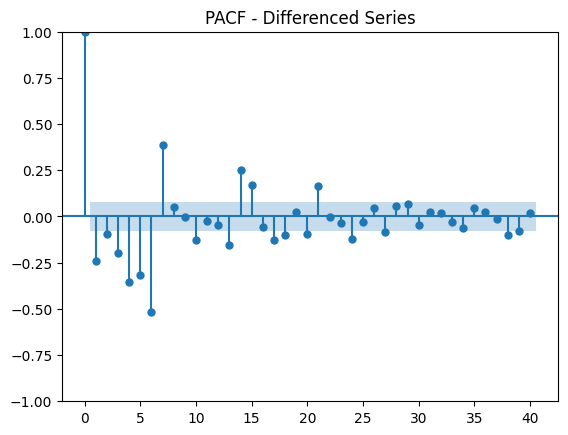

In [ ]:
plt.figure(figsize=(10,6))
plot_pacf(daily_total['y_diff'], lags=40, method='ywm')
plt.title("PACF - Differenced Series")
plt.show()

The ACF plot of the differenced series shows significant spikes at lag 1 and at seasonal lags 7, 14, 21, indicating strong weekly seasonality. The PACF plot shows a strong lag 1 component, suggesting AR(1) behavior. Therefore, a SARIMA model with weekly seasonality (m=7) is appropriate.

Seasonal Differencing

In [ ]:
daily_total['y_seasonal_diff'] = daily_total['y'] - daily_total['y'].shift(7)

daily_total = daily_total.dropna()

<Figure size 1000x600 with 0 Axes>

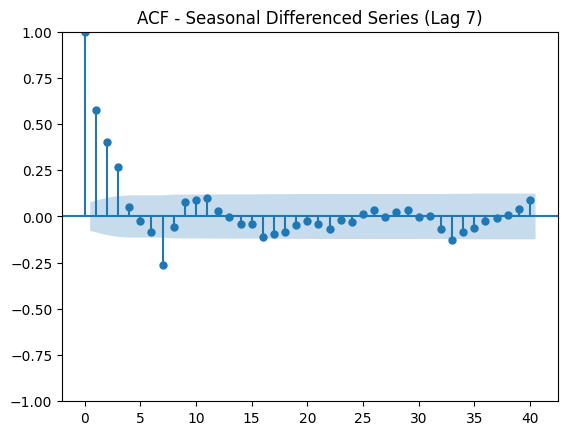

In [ ]:
plt.figure(figsize=(10,6))
plot_acf(daily_total['y_seasonal_diff'], lags=40)
plt.title("ACF - Seasonal Differenced Series (Lag 7)")
plt.show()

<Figure size 1000x600 with 0 Axes>

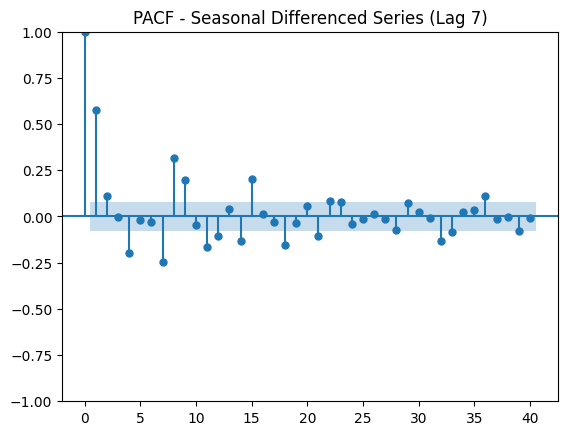

In [ ]:
plt.figure(figsize=(10,6))
plot_pacf(daily_total['y_seasonal_diff'], lags=40, method='ywm')
plt.title("PACF - Seasonal Differenced Series (Lag 7)")
plt.show()

Double Differencing

<Figure size 1000x600 with 0 Axes>

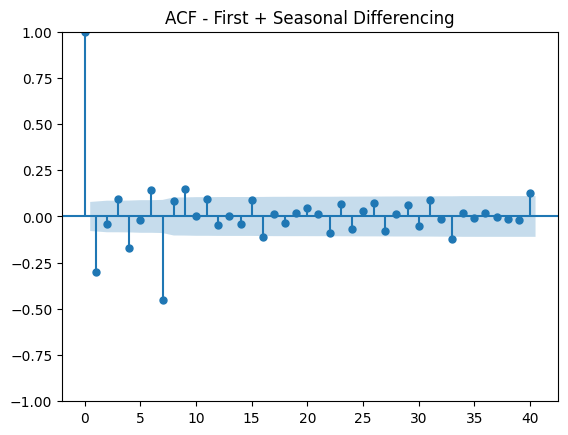

<Figure size 1000x600 with 0 Axes>

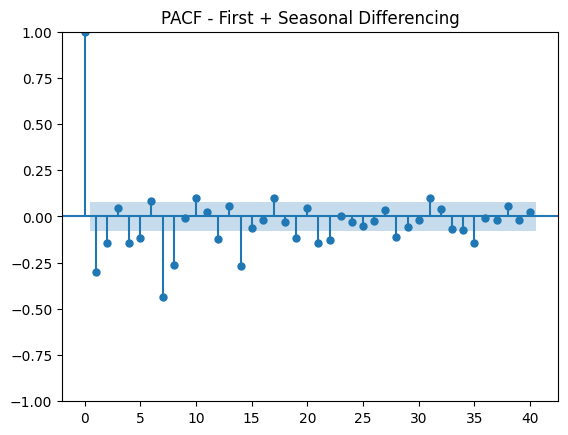

In [ ]:
daily_total['y_double_diff'] = daily_total['y'].diff().diff(7)

daily_total = daily_total.dropna()
plt.figure(figsize=(10,6))
plot_acf(daily_total['y_double_diff'], lags=40)
plt.title("ACF - First + Seasonal Differencing")
plt.show()
plt.figure(figsize=(10,6))
plot_pacf(daily_total['y_double_diff'], lags=40, method='ywm')
plt.title("PACF - First + Seasonal Differencing")
plt.show()

Decomposition

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

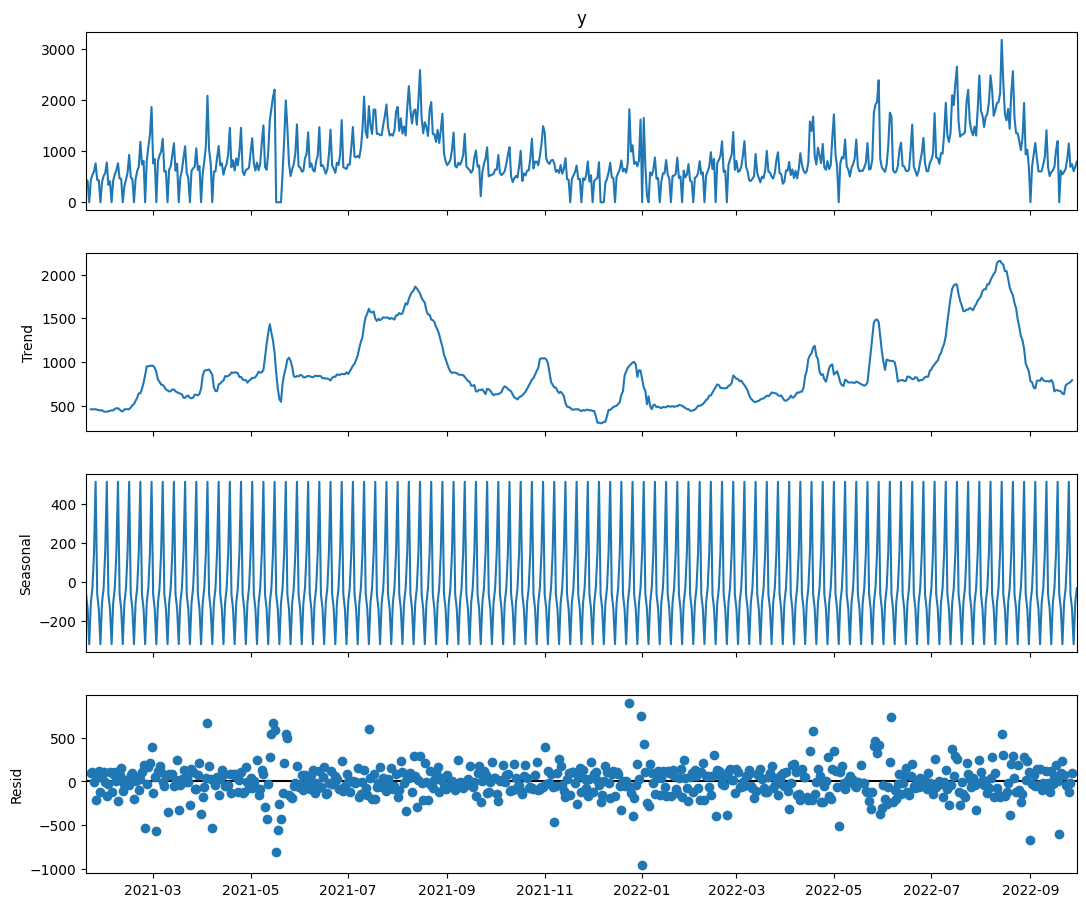

In [ ]:
decomposition = seasonal_decompose(daily_total['y'],
                                   model='additive',
                                   period=7)

fig = decomposition.plot()
fig.set_size_inches(12,10)
plt.show()

AR Model

In [ ]:
series = daily_total['y']

# 80-20 split
train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 496
Test size: 125


In [ ]:
from sklearn.metrics import mean_squared_error

def rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

In [ ]:
from statsmodels.tsa.ar_model import AutoReg

model_ar = AutoReg(train, lags=1).fit()
pred_ar = model_ar.predict(start=len(train),
                           end=len(train)+len(test)-1)

rmse_ar = rmse(test, pred_ar)
print("AR RMSE:", rmse_ar)

AR RMSE: 719.9275183548668


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


MA model

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model_ma = ARIMA(train, order=(0,0,1)).fit()
pred_ma = model_ma.forecast(steps=len(test))

rmse_ma = rmse(test, pred_ma)
print("MA RMSE:", rmse_ma)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


MA RMSE: 724.6702616347385


ARMA Model

In [ ]:
model_arma = ARIMA(train, order=(1,0,1)).fit()
pred_arma = model_arma.forecast(steps=len(test))

rmse_arma = rmse(test, pred_arma)
print("ARMA RMSE:", rmse_arma)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARMA RMSE: 724.1098679421323


ARIMA Model

In [ ]:
model_arima = ARIMA(train, order=(1,1,1)).fit()
pred_arima = model_arima.forecast(steps=len(test))

rmse_arima = rmse(test, pred_arima)
print("ARIMA RMSE:", rmse_arima)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA RMSE: 608.7730135889071


SARIMA Model

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(train,
                       order=(1,1,1),
                       seasonal_order=(1,1,1,7)).fit()

pred_sarima = model_sarima.forecast(steps=len(test))

rmse_sarima = rmse(test, pred_sarima)
print("SARIMA RMSE:", rmse_sarima)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMA RMSE: 1253.232577476749


In [ ]:
# model_sarima.plot_diagnostics(figsize=(12,8))
# plt.show()

Comparing all RMSE

In [ ]:
results = pd.DataFrame({
    "Model": ["AR", "MA", "ARMA", "ARIMA", "SARIMA"],
    "RMSE": [rmse_ar, rmse_ma, rmse_arma, rmse_arima, rmse_sarima]
})

print(results.sort_values("RMSE"))

    Model         RMSE
3   ARIMA   608.773014
0      AR   719.927518
2    ARMA   724.109868
1      MA   724.670262
4  SARIMA  1253.232577


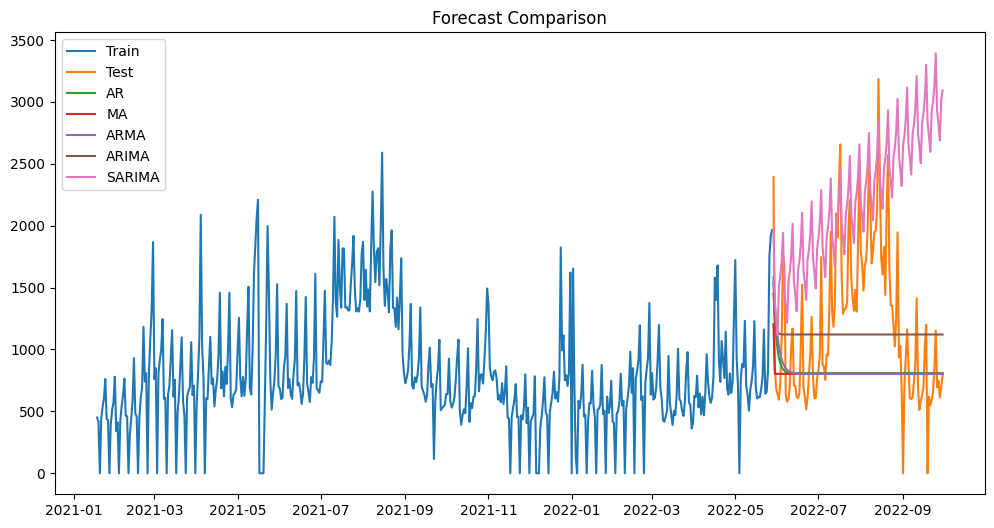

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")

plt.plot(test.index, pred_ar, label="AR")
plt.plot(test.index, pred_ma, label="MA")
plt.plot(test.index, pred_arma, label="ARMA")
plt.plot(test.index, pred_arima, label="ARIMA")
plt.plot(test.index, pred_sarima, label="SARIMA")

plt.legend()
plt.title("Forecast Comparison")
plt.show()

Among the traditional models, ARIMA achieved the lowest RMSE (608.77), indicating superior predictive performance. SARIMA performed significantly worse, suggesting that seasonal components may not be strong or were over-parameterized. Hence, the data appears to be primarily driven by trend rather than strong weekly seasonality.

Taylor Diagram

In [ ]:
def taylor_stats(observed, predicted):
    std_obs = np.std(observed, ddof=1)
    std_pred = np.std(predicted, ddof=1)
    corr = np.corrcoef(observed, predicted)[0,1]
    return std_obs, std_pred, corr

std_obs = np.std(test, ddof=1)

models = {
    "AR": pred_ar,
    "MA": pred_ma,
    "ARMA": pred_arma,
    "ARIMA": pred_arima,
    "SARIMA": pred_sarima
}

stats = {}

for name, pred in models.items():
    _, std_pred, corr = taylor_stats(test, pred)
    stats[name] = (std_pred, corr)

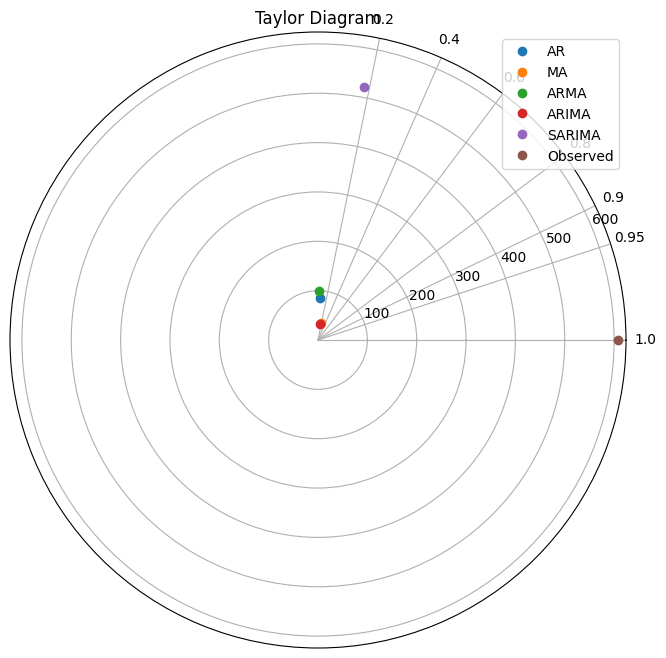

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, polar=True)

# Convert correlation to angle
for name, (std_pred, corr) in stats.items():
    theta = np.arccos(corr)   # angle
    r = std_pred              # radius
    ax.plot(theta, r, 'o', label=name)

# Plot observed reference point
ax.plot(0, std_obs, 'o', label="Observed")

# Set limits
ax.set_ylim(0, max([v[0] for v in stats.values()]) * 1.2)

# Correlation grid labels
corr_ticks = np.array([0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 1])
ax.set_thetagrids(np.degrees(np.arccos(corr_ticks)),
                  labels=[str(c) for c in corr_ticks])

ax.set_title("Taylor Diagram")
ax.legend(loc='upper right')
plt.show()

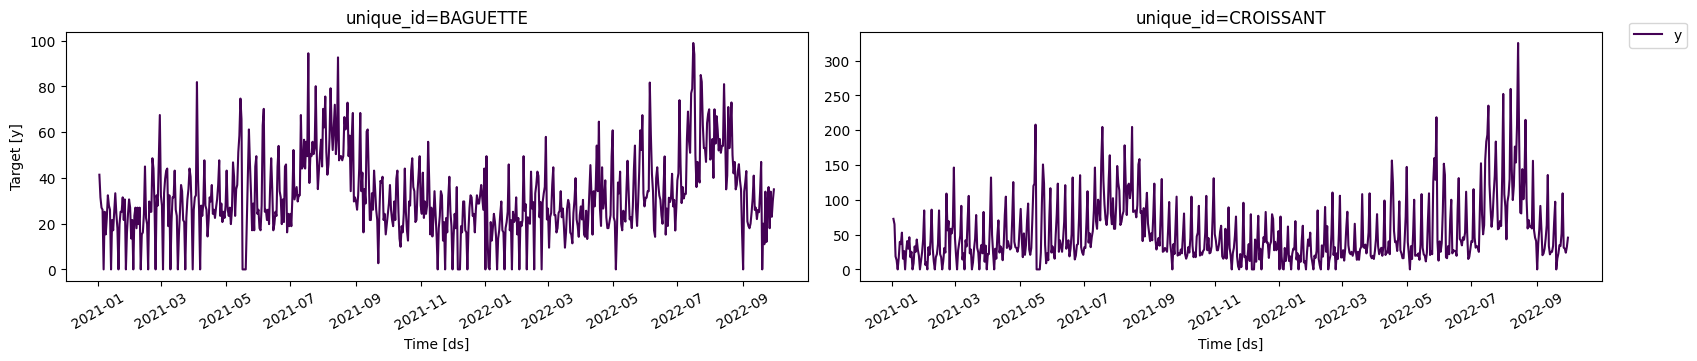

In [ ]:
plot_series(df=df, ids=['BAGUETTE', 'CROISSANT'], palette="viridis")

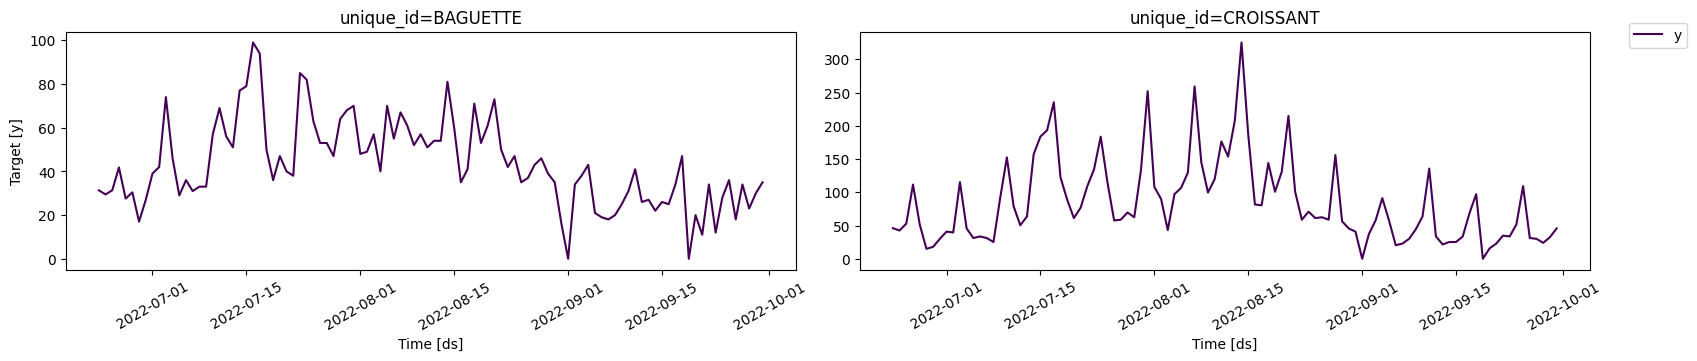

In [ ]:
plot_series(df=df, ids=['BAGUETTE', 'CROISSANT'], max_insample_length=100 ,palette="viridis")

Baseline Models


In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive

In [ ]:
horizon = 7

models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=7),
    SeasonalNaive(season_length=7)
]

In [ ]:
test = df.groupby('unique_id').tail(7)
train = df.drop(test.index).reset_index(drop=True)

In [ ]:
obj = StatsForecast(models=models, freq='D')
obj.fit(df=train)
preds = obj.predict(h=horizon)
eval_df = pd.merge(test, preds, 'left', ['ds', 'unique_id'])

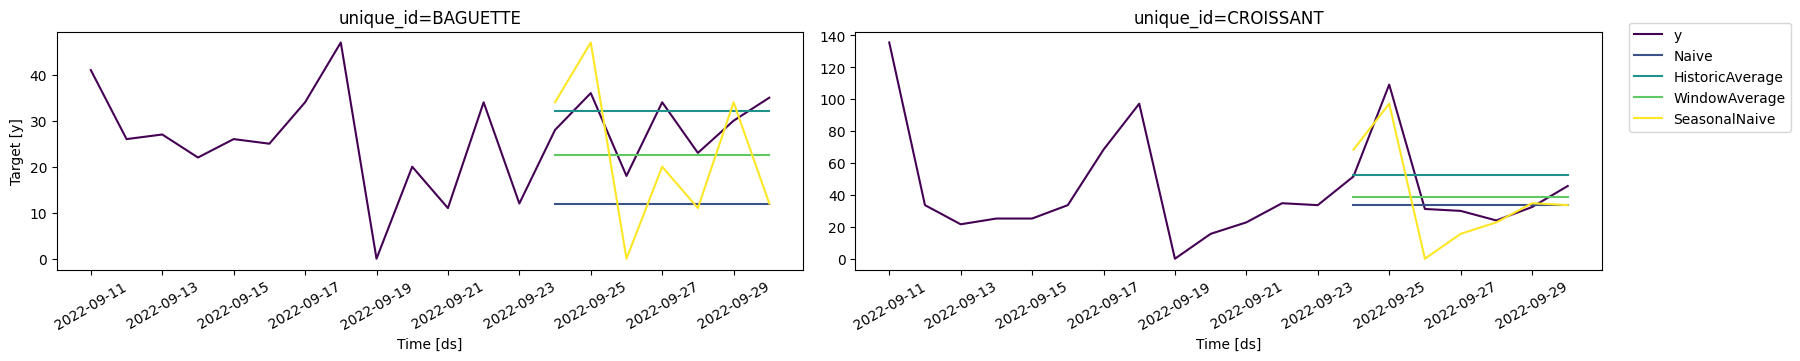

In [ ]:
plot_series(df=df,
            forecasts_df=preds,
            ids=['BAGUETTE', 'CROISSANT'],
            max_insample_length=20,
            palette='viridis')

In [ ]:
evaluation = evaluate(
    df = eval_df,
    metrics=[mae],
)
evaluation.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,mae,2.857143,6.961771,3.469388,4.285714
1,ARMORICAIN,mae,NaN,NaN,NaN,NaN
2,ARTICLE 295,mae,NaN,NaN,NaN,NaN
3,BAGUETTE,mae,17.142857,5.455193,7.877551,12.571429
4,BAGUETTE APERO,mae,0.000000,0.537572,0.642857,0.642857


In [ ]:
evaluation = evaluation.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
evaluation

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,6.07604,5.253154,5.016269,4.624203


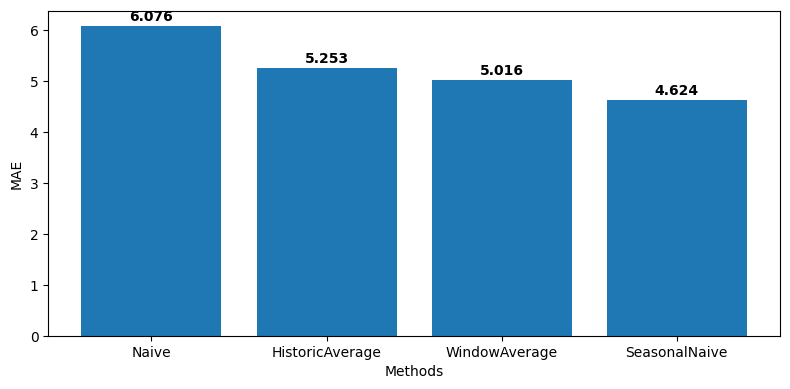

In [ ]:
methods = evaluation.columns[1:].tolist()
values = evaluation.iloc[0, 1:].tolist()

plt.figure(figsize=(8, 4))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()